### 서울시 행정동별 요양시설 유효공급 격차 ② 동별 수요 추정

> 검토 정정: 65세 이상 1~2등급은 잠재 중증 돌봄 지표이며 실제 입소 수요·대기자 수가 아니다. 공통 인정률은 연령 구조 표준화 선택으로, 주소 이동 교정이 입증된 것은 아니다. 구별 인정률 B와 3등급 포함 수요를 민감도로 비교한다.

보고서 문장은 독립 재계산 산출물의 입력 해시가 일치할 때만 표시한다. 자료를 바꾸면 `python 검토_재계산.py`를 실행한다.


등급판정 자료는 시군구 단위이므로 행정동별 중증 돌봄 수요(장기요양 1~2등급 인정자 수)는 직접 관측되지 않는다. 본 노트북은 동별 연령 구조에 연령별 인정률을 곱하는 간접표준화로 동별 수요를 추정한다.

$$D_i = \sum_a P_{ia} \times r_a$$

- $P_{ia}$: 동 $i$의 연령군 $a$ 주민등록인구(2024-07-31, 01 노트북 산출물)
- $r_a$: 연령군 $a$의 장기요양 1~2등급 인정률(등급판정 현황 2024-07-31, 실거주지 기준)

### 1. 분석 기준

- 연령군: 65~74세, 75~84세, 85세 이상. 등급판정 자료의 연령은 **신청 당시** 연령이고 인구는 2024-07-31 현재 연령이므로, 5세 구간 경계에서 생기는 어긋남을 줄이도록 10세 단위로 넓게 묶는다. 65세 미만 인정자(서울 1~2등급의 약 5%)는 연령 구조로 배분할 근거가 약해 제외한다.
- 수요 버전
  - **A**: 서울 공통 연령별 인정률. 버퍼 지역(경기·인천)에도 서울 인정률을 적용한다.
  - **B**: 구별 연령별 인정률. 경기·인천 읍면동은 소속 시군구 인정률을 쓴다. 등급판정 자료에서 경기도는 구가 있는 시도 시 단위(예: 고양시)로만 제공되므로 시 단위 인정률을 쓴다.
  - **B-EB**: B의 구×연령 인정률을 서울 인정률 쪽으로 축소한 경험적 베이즈 추정(선택)
- 민감도: 1~3등급 수요(A3, B3)
- 인정률의 분모는 01 노트북과 같은 행정안전부 주민등록인구(거주자+거주불명자+재외국민)이고, 분자는 실거주지 기준 인정자 수다. 두 기준의 차이는 작다고 보고 보정하지 않는다.

In [1]:
import re

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy.stats import spearmanr

import config as C

pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["font.family"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def age_group(start_age):
    """5세 구간 시작 나이를 config.AGE_GROUPS의 연령군 이름으로 바꾼다. 65세 미만은 None."""
    for name, (lo, hi) in C.AGE_GROUPS.items():
        if start_age >= lo and (hi is None or start_age <= hi):
            return name
    return None


AGE_ORDER = list(C.AGE_GROUPS)

### 2. 인구: 동별·지역별 연령군 인구

동별 인구는 01 노트북 캐시를 쓴다. 인정률의 분모는 등급판정 자료와 같은 지역 단위(서울·인천은 구·군, 경기는 시·군)의 **전체** 인구여야 하므로, 01 노트북이 내려받은 행정안전부 원자료에서 서울·경기·인천의 모든 읍면동을 지역 단위로 합산한다. 지역 이름은 행정구역명의 두 번째 단어(예: `경기도 고양시 덕양구 주교동` → 고양시)로 등급판정 자료와 맞춘다.

In [2]:
year, month = C.POPULATION_YEAR_MONTH
pop_raw = pd.read_csv(
    C.ASSET_DIR / f"행정안전부_읍면동_5세연령별_주민등록인구_{year}{month}.csv", encoding="cp949", dtype=str
)
pop_raw["코드"] = pop_raw["행정구역"].str.extract(r"\((\d{10})\)")[0]
pop_raw = pop_raw.loc[pop_raw["코드"].str[:2].isin(C.SIDO_CODES) & (pop_raw["코드"].str[5:] != "00000")]
age_cols = [c for c in pop_raw.columns if re.match(rf"{year}년{month}월_계_\d+", c)]
region_pop = (
    pop_raw.assign(
        시도=pop_raw["코드"].str[:2].map(C.SIDO_CODES).str[:2],
        지역=pop_raw["행정구역"].str.split().str[1],
    )
    .melt(id_vars=["시도", "지역"], value_vars=age_cols, var_name="열", value_name="인구")
    .assign(
        연령군=lambda d: d["열"].str.extract(r"_(\d+)(?:~|세)")[0].astype(int).map(age_group),
        인구=lambda d: pd.to_numeric(d["인구"].str.replace(",", "", regex=False)),
    )
    .dropna(subset=["연령군"])
    .groupby(["시도", "지역", "연령군"], as_index=False)["인구"].sum()
)

study_dong = gpd.read_file(C.OUTPUT_DIR / "행정동_분석범위.gpkg")
dong_pop = pd.read_csv(C.OUTPUT_DIR / "행정동_성별_5세_인구.csv", dtype={"행정동코드": str})
dong_pop["연령군"] = dong_pop["연령"].map(age_group)
P = (
    dong_pop.dropna(subset=["연령군"])
    .pivot_table(index="행정동코드", columns="연령군", values="인구", aggfunc="sum")
    .reindex(columns=AGE_ORDER)
)
# 경계 자료의 구가 있는 시는 `수원시장안구`처럼 붙어 있으므로 시 이름만 남긴다(등급판정 자료와 같은 단위).
study_dong["지역"] = study_dong["시군구"].str.replace(r"^(\S+?시)\S+구$", r"\1", regex=True)
study_dong["시도약칭"] = study_dong["시도"].str[:2]
study_dong = study_dong.merge(P, left_on="행정동코드", right_index=True, how="left", validate="one_to_one")
assert study_dong[AGE_ORDER].notna().all().all()

# 동별 인구를 지역별로 합하면 지역 인구와 같아야 한다(서울 구 단위).
seoul_check = study_dong.loc[study_dong["서울"]].groupby("지역")[AGE_ORDER].sum().stack()
seoul_region = region_pop.loc[region_pop["시도"].eq("서울")].set_index(["지역", "연령군"])["인구"]
assert (seoul_check.sort_index() == seoul_region.sort_index()).all()
print(f"분석 범위 동 {len(study_dong)}개, 인정률 산출 지역 {region_pop[['시도', '지역']].drop_duplicates().shape[0]}개")

분석 범위 동 1183개, 인정률 산출 지역 66개


### 3. 등급판정 자료: 지역×연령군 인정자 수

In [3]:
grade_raw = pd.read_csv(C.GRADE_FILE, encoding="cp949")
grade_raw.columns = [c.strip() for c in grade_raw.columns]
for col in ["시도", "시군구", "연령구분"]:
    grade_raw[col] = grade_raw[col].astype(str).str.strip()
GRADE_COLS = ["1등급", "2등급", "3등급", "4등급", "5등급"]
for col in GRADE_COLS:
    grade_raw[col] = pd.to_numeric(grade_raw[col].astype(str).str.replace(",", "", regex=False))

grade_raw["시작나이"] = grade_raw["연령구분"].str.extract(r"^(\d+)")[0].astype(int)
grade_raw.loc[grade_raw["연령구분"].str.contains("미만"), "시작나이"] = 0
grade_raw["연령군"] = grade_raw["시작나이"].map(age_group)
grade_raw["g12"] = grade_raw["1등급"] + grade_raw["2등급"]
grade_raw["g123"] = grade_raw["g12"] + grade_raw["3등급"]
grade_raw["g45"] = grade_raw["4등급"] + grade_raw["5등급"]

grade = (
    grade_raw.loc[grade_raw["시도"].isin(["서울", "경기", "인천"]) & grade_raw["연령군"].notna()]
    .rename(columns={"시군구": "지역"})
    .groupby(["시도", "지역", "연령군"], as_index=False)[["g12", "g123", "g45"]].sum()
    .merge(region_pop, on=["시도", "지역", "연령군"], how="left", validate="one_to_one")
)
assert grade["인구"].notna().all(), grade.loc[grade["인구"].isna(), ["시도", "지역"]].drop_duplicates()
assert set(study_dong[["시도약칭", "지역"]].itertuples(index=False, name=None)) <= set(
    grade[["시도", "지역"]].itertuples(index=False, name=None)
)

seoul_all_ages = grade_raw.loc[grade_raw["시도"].eq("서울"), "g12"].sum()
seoul_65 = grade.loc[grade["시도"].eq("서울"), "g12"].sum()
display(Markdown(
    f"서울 1~2등급 인정자 {seoul_all_ages:,}명 중 65세 이상 {seoul_65:,}명({seoul_65 / seoul_all_ages:.1%})을 수요로 배분한다."
))

서울 1~2등급 인정자 23,249명 중 65세 이상 22,074명(94.9%)을 수요로 배분한다.

### 4. 연령별 인정률

- 버전 A: $r_a = \sum_{g \in 서울} O_{ga} / \sum_{g \in 서울} P_{ga}$
- 버전 B: $r_{ga} = O_{ga} / P_{ga}$
- 버전 B-EB: 구×연령 칸마다 $\hat r_{ga} = w_{ga} \cdot r_{ga} + (1 - w_{ga}) \cdot r_a$, $w_{ga} = \tau_a^2 / (\tau_a^2 + r_a / P_{ga})$. $\tau_a^2$는 구 간 참 인정률의 분산으로, 인구가중 분산에서 포아송 잡음 몫을 뺀 적률 추정값(Marshall, 1991)이다. 서울 구에만 적용하고 경기·인천은 B와 같게 둔다.

In [4]:
def add_rates(df, count):
    seoul = df.loc[df["시도"].eq("서울")].groupby("연령군")[[count, "인구"]].sum()
    r_seoul = seoul[count] / seoul["인구"]
    out = df.assign(r_A=df["연령군"].map(r_seoul), r_B=df[count] / df["인구"])

    # 경험적 베이즈(서울 구만)
    out["r_BEB"] = out["r_B"]
    for age, m in r_seoul.items():
        s = out["시도"].eq("서울") & out["연령군"].eq(age)
        p, r = out.loc[s, "인구"], out.loc[s, "r_B"]
        tau2 = max(0.0, (p * (r - m) ** 2).sum() / p.sum() - m / p.mean())
        w = tau2 / (tau2 + m / p)
        out.loc[s, "r_BEB"] = w * r + (1 - w) * m
    return out, r_seoul


rates12, r_seoul12 = add_rates(grade, "g12")
rates123, r_seoul123 = add_rates(grade, "g123")

rate_table = pd.DataFrame({
    "서울 인구": rates12.loc[rates12["시도"].eq("서울")].groupby("연령군")["인구"].sum(),
    "1~2등급": rates12.loc[rates12["시도"].eq("서울")].groupby("연령군")["g12"].sum(),
    "인정률(1~2)": r_seoul12,
    "인정률(1~3)": r_seoul123,
    "구 간 최소(1~2)": rates12.loc[rates12["시도"].eq("서울")].groupby("연령군")["r_B"].min(),
    "구 간 최대(1~2)": rates12.loc[rates12["시도"].eq("서울")].groupby("연령군")["r_B"].max(),
}).reindex(AGE_ORDER)
rate_table.rename_axis("연령군").to_csv(C.OUTPUT_DIR / "인정률_서울.csv")  # 07 미래 수요에서 같은 인정률을 쓴다
display(rate_table.style.format({
    "서울 인구": "{:,.0f}", "1~2등급": "{:,.0f}", "인정률(1~2)": "{:.2%}", "인정률(1~3)": "{:.2%}",
    "구 간 최소(1~2)": "{:.2%}", "구 간 최대(1~2)": "{:.2%}",
}))

,서울 인구,1~2등급,인정률(1~2),인정률(1~3),구 간 최소(1~2),구 간 최대(1~2)
연령군,,,,,,
65~74세,"1,049,382","3,535",0.34%,0.93%,0.15%,0.44%
75~84세,"563,851","8,582",1.52%,4.55%,0.95%,2.06%
85세 이상,"165,897","9,957",6.00%,16.17%,4.04%,8.39%


### 5. 동별 수요

In [5]:
def dong_demand(rates, col):
    r = rates.pivot_table(index=["시도", "지역"], columns="연령군", values=col).reindex(columns=AGE_ORDER)
    r = r.loc[list(zip(study_dong["시도약칭"], study_dong["지역"]))].to_numpy()
    return (study_dong[AGE_ORDER].to_numpy() * r).sum(axis=1)


study_dong["D_A"] = dong_demand(rates12, "r_A")
study_dong["D_B"] = dong_demand(rates12, "r_B")
study_dong["D_BEB"] = dong_demand(rates12, "r_BEB")
study_dong["D_A3"] = dong_demand(rates123, "r_A")
study_dong["D_B3"] = dong_demand(rates123, "r_B")
DEMAND_COLS = ["D_A", "D_B", "D_BEB", "D_A3", "D_B3"]

# 검증: 버전 B의 동별 수요를 구별로 합하면 실제 구별 65세 이상 1~2등급 인정자 수와 같다.
seoul_dong = study_dong.loc[study_dong["서울"]]
by_gu = seoul_dong.groupby("지역")[["D_A", "D_B", "D_B3"]].sum()
actual = grade.loc[grade["시도"].eq("서울")].groupby("지역")[["g12", "g123"]].sum()
assert (by_gu["D_B"] - actual["g12"]).abs().max() < 0.5
assert (by_gu["D_B3"] - actual["g123"]).abs().max() < 0.5
assert abs(by_gu["D_A"].sum() - actual["g12"].sum()) < 0.5  # A는 서울 합계만 같다

# 버퍼의 경기·인천 동은 지역의 일부만 포함되므로 지역 합계 검증은 서울에만 적용한다.
study_dong.drop(columns="geometry").to_csv(C.OUTPUT_DIR / "동별_수요.csv", index=False)
display(Markdown(
    f"- 버전 B의 동별 수요를 구별로 합한 값과 실제 구별 인정자 수의 최대 차이: "
    f"{(by_gu['D_B'] - actual['g12']).abs().max():.2e}명\n"
    f"- 서울 동 수요 합계: A {seoul_dong['D_A'].sum():,.0f}명, B {seoul_dong['D_B'].sum():,.0f}명, "
    f"1~3등급 A {seoul_dong['D_A3'].sum():,.0f}명"
))
seoul_dong[DEMAND_COLS].describe().T

- 버전 B의 동별 수요를 구별로 합한 값과 실제 구별 인정자 수의 최대 차이: 0.00e+00명
- 서울 동 수요 합계: A 22,074명, B 22,074명, 1~3등급 A 62,277명

,count,mean,std,min,25%,50%,75%,max
D_A,426.00,51.82,21.54,0.05,36.76,48.91,65.27,118.72
D_B,426.00,51.82,23.70,0.07,35.76,49.11,65.63,136.80
D_BEB,426.00,51.89,23.31,0.07,36.23,49.29,65.43,133.98
D_A3,426.00,146.19,60.75,0.16,103.56,138.24,184.12,334.43
D_B3,426.00,146.19,66.31,0.17,100.21,136.13,186.05,371.63


### 6. 점검: 시설 입소에 따른 주소 이동이 버전 B를 부풀리는가

요양시설에 입소하면서 주소를 시설로 옮긴 사람은 시설 소재 구의 인정자로 잡힌다. 그렇다면 정원이 많은 구일수록 연령구조로 기대되는 것보다 인정자가 많게 나오고, 버전 B는 시설이 많은 구의 수요를 부풀린다. 그러나 시설·수요·연령의 공간 분포가 함께 변하므로 편향 방향을 일반적으로 단정하지 않는다. 아래 대조군 점검은 주소 이동 가설의 탐색이며 교정 효과의 증명이 아니다.

- 구별 연령표준화 인정비: $SRR_g = O_g / E_g$, $E_g = \sum_a P_{ga} r_a$ (서울 공통 인정률 기준 기대 인정자 수)
- 구별 입소 정원: 75세 이상 1,000명당 정원(기존 자치구 분석과 같은 정의)
- 대조: 시설 입소가 드문 4~5등급의 SRR도 같은 방식으로 계산한다. 주소 이동 때문이라면 1~2등급에서만 상관이 나타나야 하고, 구별 건강 수준·신청 성향 차이 때문이라면 4~5등급에서도 비슷하게 나타난다.

In [6]:
general = pd.read_excel(C.FACILITY_FILE, sheet_name="일반현황", dtype={"장기요양기관코드": str})
capacity = pd.read_excel(C.FACILITY_FILE, sheet_name="입소인원", dtype={"장기요양기관코드": str})
region = general["시도 시군구 법정동명"].str.extract(r"^(\S+)\s+(\S+)")
region_fallback = general["기관별 상세주소"].str.extract(r"^(\S+)\s+(\S+)")
general["시도"] = region[0].fillna(region_fallback[0])
general["지역"] = region[1].fillna(region_fallback[1])
gu_capacity = (
    capacity.loc[capacity["기관유형코드"].isin(C.RESIDENTIAL_CODES)]
    .merge(general.loc[general["시도"].eq("서울특별시"), ["장기요양기관코드", "지역"]], on="장기요양기관코드")
    .groupby("지역").agg(정원=("정원", "sum"), 현원=("현원", "sum"))
)
assert gu_capacity["정원"].sum() == 16_055

seoul_rates = grade.loc[grade["시도"].eq("서울")]
r45 = seoul_rates.groupby("연령군")["g45"].sum() / seoul_rates.groupby("연령군")["인구"].sum()
check = (
    seoul_rates.assign(
        E12=seoul_rates["인구"] * seoul_rates["연령군"].map(r_seoul12),
        E45=seoul_rates["인구"] * seoul_rates["연령군"].map(r45),
    )
    .groupby("지역")[["g12", "E12", "g45", "E45"]].sum()
    .join(gu_capacity)
)
check["SRR_12"] = check["g12"] / check["E12"]
check["SRR_45"] = check["g45"] / check["E45"]
pop75 = region_pop.loc[region_pop["시도"].eq("서울") & region_pop["연령군"].isin(["75~84세", "85세 이상"])].groupby("지역")["인구"].sum()
assert pop75.sum() == 729_748
check["75세이상_천명당_정원"] = check["정원"] / pop75 * 1_000
check["초과인정자"] = check["g12"] - check["E12"]

rho12, p12 = spearmanr(check["75세이상_천명당_정원"], check["SRR_12"])
rho45, p45 = spearmanr(check["75세이상_천명당_정원"], check["SRR_45"])
rho_srr, p_srr = spearmanr(check["SRR_12"], check["SRR_45"])
slope = np.polyfit(check["정원"], check["초과인정자"], 1)[0]
resident_share = gu_capacity["현원"].sum() / check["g12"].sum()

display(Markdown(
    f"- 1,000명당 정원 vs 1~2등급 SRR: 스피어만 **{rho12:.2f}** (p = {p12:.3f})\n"
    f"- 1,000명당 정원 vs 4~5등급 SRR(대조): 스피어만 **{rho45:.2f}** (p = {p45:.3f})\n"
    f"- 1~2등급 SRR vs 4~5등급 SRR: 스피어만 {rho_srr:.2f} (p = {p_srr:.3f})\n"
    f"- 정원 1석당 초과 인정자(기대 대비, 선형 기울기): {slope:.2f}명\n"
    f"- 참고: 서울 입소시설 현원 {gu_capacity['현원'].sum():,}명 = 서울 65세 이상 1~2등급 인정자의 {resident_share:.0%} 규모"
))
display(
    check.sort_values("SRR_12", ascending=False)[["g12", "E12", "SRR_12", "SRR_45", "정원", "75세이상_천명당_정원"]]
    .style.format({"g12": "{:,.0f}", "E12": "{:,.0f}", "SRR_12": "{:.2f}", "SRR_45": "{:.2f}", "정원": "{:,.0f}", "75세이상_천명당_정원": "{:.1f}"})
)

- 1,000명당 정원 vs 1~2등급 SRR: 스피어만 **0.34** (p = 0.097)
- 1,000명당 정원 vs 4~5등급 SRR(대조): 스피어만 **0.62** (p = 0.001)
- 1~2등급 SRR vs 4~5등급 SRR: 스피어만 0.16 (p = 0.452)
- 정원 1석당 초과 인정자(기대 대비, 선형 기울기): 0.13명
- 참고: 서울 입소시설 현원 14,588명 = 서울 65세 이상 1~2등급 인정자의 66% 규모

,g12,E12,SRR_12,SRR_45,정원,75세이상_천명당_정원
지역,,,,,,
강동구,"1,264",950,1.33,1.01,738,23.7
강남구,"1,334","1,072",1.24,0.72,303,8.4
성북구,"1,327","1,076",1.23,1.00,872,24.4
구로구,"1,133",954,1.19,1.18,981,30.5
중랑구,"1,143",965,1.18,1.03,"1,165",36.2
영등포구,967,865,1.12,1.03,260,9.2
종로구,444,412,1.08,0.75,400,30.3
서초구,884,822,1.08,0.70,322,11.7
도봉구,979,920,1.06,1.05,"1,162",38.5


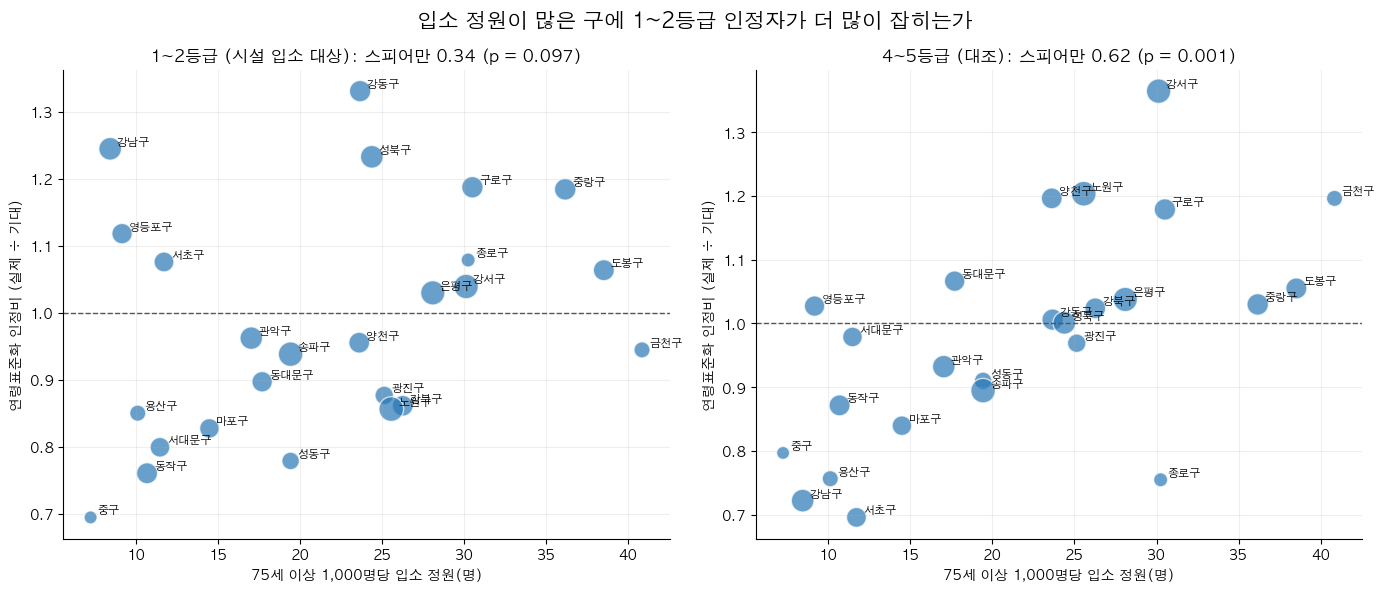

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for ax, col, rho, p, title in (
    (axes[0], "SRR_12", rho12, p12, "1~2등급 (시설 입소 대상)"),
    (axes[1], "SRR_45", rho45, p45, "4~5등급 (대조)"),
):
    ax.scatter(check["75세이상_천명당_정원"], check[col], s=check["E12"] / 4,
               color="#2878B5", alpha=0.7, edgecolor="white")
    for gu, row in check.iterrows():
        ax.annotate(gu, (row["75세이상_천명당_정원"], row[col]), xytext=(5, 3), textcoords="offset points", fontsize=8)
    ax.axhline(1, color="#555555", linestyle="--", linewidth=1)
    ax.set_title(f"{title}: 스피어만 {rho:.2f} (p = {p:.3f})", fontsize=12)
    ax.set_xlabel("75세 이상 1,000명당 입소 정원(명)")
    ax.set_ylabel("연령표준화 인정비 (실제 ÷ 기대)")
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("입소 정원이 많은 구에 1~2등급 인정자가 더 많이 잡히는가", fontsize=15)
plt.tight_layout()
fig.savefig(C.OUTPUT_DIR / "수요_주소이동_점검.png", dpi=200, bbox_inches="tight")
plt.show()

### 7. 동별 수요 지도

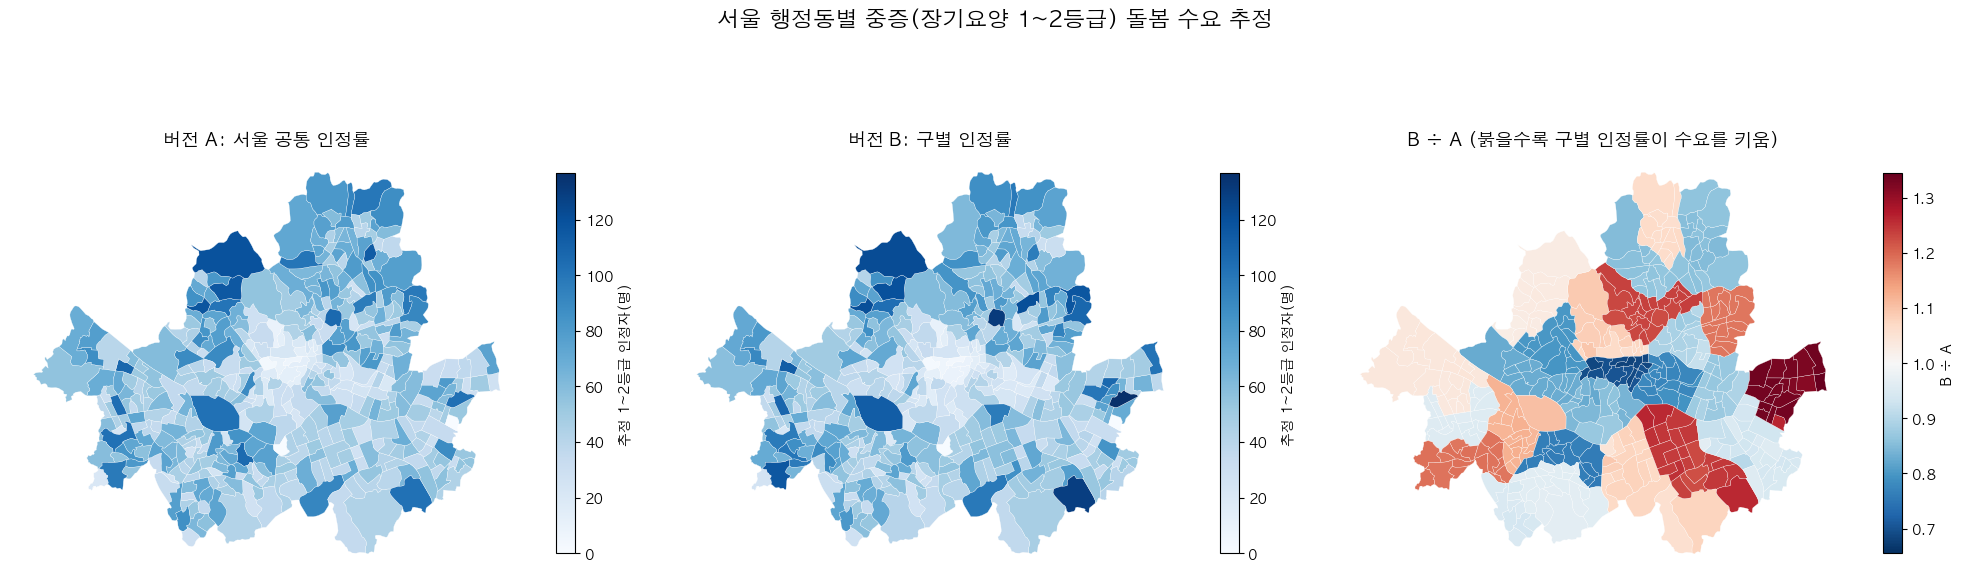

In [8]:
seoul_map = study_dong.loc[study_dong["서울"]].copy()
seoul_map["B_A_비"] = seoul_map["D_B"] / seoul_map["D_A"]
vmax = seoul_map[["D_A", "D_B"]].max().max()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, col, title in ((axes[0], "D_A", "버전 A: 서울 공통 인정률"), (axes[1], "D_B", "버전 B: 구별 인정률")):
    seoul_map.plot(column=col, ax=ax, cmap="Blues", vmin=0, vmax=vmax, edgecolor="white", linewidth=0.2,
                   legend=True, legend_kwds={"shrink": 0.6, "label": "추정 1~2등급 인정자(명)"})
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()
lim = max(abs(seoul_map["B_A_비"] - 1).max(), 0.01)
seoul_map.plot(column="B_A_비", ax=axes[2], cmap="RdBu_r", vmin=1 - lim, vmax=1 + lim, edgecolor="white",
               linewidth=0.2, legend=True, legend_kwds={"shrink": 0.6, "label": "B ÷ A"})
axes[2].set_title("B ÷ A (붉을수록 구별 인정률이 수요를 키움)", fontsize=13)
axes[2].set_axis_off()
fig.suptitle("서울 행정동별 중증(장기요양 1~2등급) 돌봄 수요 추정", fontsize=16)
plt.tight_layout()
fig.savefig(C.OUTPUT_DIR / "동별_수요_지도.png", dpi=200, bbox_inches="tight")
plt.show()

### 8. 버전 간 비교

In [9]:
compare = pd.DataFrame(
    [[spearmanr(seoul_map[a], seoul_map[b])[0] for b in DEMAND_COLS] for a in DEMAND_COLS],
    index=DEMAND_COLS, columns=DEMAND_COLS,
)
beb_shift = (seoul_map["D_BEB"] / seoul_map["D_B"] - 1).abs()
display(Markdown(
    f"동 순위의 스피어만 상관(서울 426개 동). 경험적 베이즈 축소로 동별 수요가 바뀐 폭은 "
    f"중앙값 {beb_shift.median():.1%}, 최대 {beb_shift.max():.1%}다."
))
display(compare.style.format("{:.3f}").background_gradient(cmap="Blues", vmin=0.9, vmax=1))

동 순위의 스피어만 상관(서울 426개 동). 경험적 베이즈 축소로 동별 수요가 바뀐 폭은 중앙값 1.3%, 최대 11.5%다.

,D_A,D_B,D_BEB,D_A3,D_B3
D_A,1.000,0.929,0.940,1.000,0.961
D_B,0.929,1.000,0.999,0.930,0.971
D_BEB,0.940,0.999,1.000,0.941,0.975
D_A3,1.000,0.930,0.941,1.000,0.961
D_B3,0.961,0.971,0.975,0.961,1.000


### 9. 보고서 문장

In [ ]:
q10, q50, q90 = seoul_map["D_A"].quantile([0.1, 0.5, 0.9])
top = seoul_map.nlargest(1, "D_A").iloc[0]
tiny = seoul_map.loc[seoul_map[AGE_ORDER].sum(axis=1) < 100, "행정동명"].str.split().str[-1]


In [1]:
from 검토_재계산 import reviewed_sentences

for sentence in reviewed_sentences("02"):
    print(sentence)


동별 연령 구조에 서울 공통 1~2등급 인정률을 곱한 잠재 중증 돌봄 지표다. 서울 65세 이상 합계는 22,074명이다. 실제 입소·대기 수요와 같지 않으며 재가·병원 이용과 일부 3~5등급 입소자를 별도 고려해야 한다.
공통 인정률은 구별 건강·신청 성향을 고정한 연령 구조 비교를 위한 선택이다. 주소 이동 교정이 입증된 것은 아니다. 기존 점검에서 구별 표준화 인정비와 정원 상관은 1~2등급 0.34(p=0.10), 4~5등급 0.62(p=0.001)였으므로 주소 이동만으로 설명하지 않는다. 구별 인정률 버전 B를 민감도로 함께 비교한다.


### 출처

- 국민건강보험공단_노인장기요양보험 등급판정 현황(2024-07-31): https://www.data.go.kr/data/3051421/fileData.do
- 행정안전부 주민등록 인구통계(2024-07-31): https://jumin.mois.go.kr/ageStatMonth.do
- 국민건강보험공단_장기요양기관 시설별 현황(2024-07-16): https://www.data.go.kr/data/15124763/fileData.do
- Marshall, R. J. (1991). Mapping disease and mortality rates using empirical Bayes estimators. *Applied Statistics*, 40(2), 283–294.